<a href="https://colab.research.google.com/github/FaizAkmal33/datamining/blob/main/UTS_DataMining_Faiz_Akmal_Al_Aisy_169.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import semua library yang dibutuhkan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

# Set style visualisasi
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

print('✅ Semua library berhasil diimport!')

✅ Semua library berhasil diimport!


In [3]:
# ============================================================
# OPSI A: Upload manual via Google Colab
# ============================================================
from google.colab import files
uploaded = files.upload()  # Upload data_training.csv & data_testing.csv

# ============================================================
# OPSI B: Load langsung dari path (jika sudah upload)
# ============================================================
train_path = 'data_training.csv'
test_path  = 'data_testing.csv'

df_train = pd.read_csv(train_path)
df_test  = pd.read_csv(test_path)

print(f'✅ Data Training : {df_train.shape[0]} baris, {df_train.shape[1]} kolom')
print(f'✅ Data Testing  : {df_test.shape[0]} baris, {df_test.shape[1]} kolom')

Saving data_testing.csv to data_testing.csv
Saving data_training.csv to data_training.csv
✅ Data Training : 857 baris, 13 kolom
✅ Data Testing  : 286 baris, 12 kolom


In [4]:
# Tampilkan 5 baris pertama data training
print('=== PREVIEW DATA TRAINING ===')
df_train.head()

=== PREVIEW DATA TRAINING ===


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8,5,1366
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2,5,103
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0,7,942
3,12.9,0.500,0.55,2.8,0.072,7.0,24.0,1.00012,3.09,0.68,10.9,6,811
4,8.4,0.360,0.32,2.2,0.081,32.0,79.0,0.99640,3.30,0.72,11.0,6,918


In [5]:
# Tampilkan 5 baris pertama data testing
print('=== PREVIEW DATA TESTING ===')
df_test.head()

=== PREVIEW DATA TESTING ===


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,Id
0,6.8,0.61,0.04,1.5,0.057,5.0,10.0,0.99525,3.42,0.60,9.500000,222
1,6.9,0.84,0.21,4.1,0.074,16.0,65.0,0.99842,3.53,0.72,9.233333,1514
2,7.0,0.58,0.12,1.9,0.091,34.0,124.0,0.99560,3.44,0.48,10.500000,417
3,7.8,0.48,0.68,1.7,0.415,14.0,32.0,0.99656,3.09,1.06,9.100000,754
4,12.5,0.60,0.49,4.3,0.100,5.0,14.0,1.00100,3.25,0.74,11.900000,516


In [6]:
# Informasi tipe data dan non-null count
print('=== INFO DATA TRAINING ===')
df_train.info()

=== INFO DATA TRAINING ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 857 entries, 0 to 856
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         857 non-null    float64
 1   volatile acidity      857 non-null    float64
 2   citric acid           857 non-null    float64
 3   residual sugar        857 non-null    float64
 4   chlorides             857 non-null    float64
 5   free sulfur dioxide   857 non-null    float64
 6   total sulfur dioxide  857 non-null    float64
 7   density               857 non-null    float64
 8   pH                    857 non-null    float64
 9   sulphates             857 non-null    float64
 10  alcohol               857 non-null    float64
 11  quality               857 non-null    int64  
 12  Id                    857 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 87.2 KB


In [7]:
# Statistik deskriptif
print('=== STATISTIK DESKRIPTIF DATA TRAINING ===')
df_train.describe().round(3)

=== STATISTIK DESKRIPTIF DATA TRAINING ===


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,857.000,857.000,857.000,857.000,857.000,857.000,857.000,857.000,857.000,857.000,857.000,857.000,857.000
mean,8.262,0.529,0.267,2.506,0.087,15.783,45.978,0.997,3.313,0.657,10.430,5.653,813.749
std,1.702,0.179,0.195,1.294,0.049,10.300,31.692,0.002,0.152,0.167,1.067,0.822,463.807
min,4.600,0.120,0.000,0.900,0.012,1.000,6.000,0.990,2.740,0.390,8.400,3.000,0.000
25%,7.100,0.395,0.090,1.900,0.070,7.000,21.000,0.996,3.210,0.550,9.500,5.000,413.000
50%,7.900,0.520,0.250,2.200,0.079,14.000,38.000,0.997,3.310,0.620,10.200,6.000,814.000
75%,9.100,0.640,0.420,2.600,0.090,21.000,63.000,0.998,3.400,0.730,11.100,6.000,1214.000
max,15.600,1.580,1.000,15.500,0.611,68.000,278.000,1.003,4.010,2.000,14.000,8.000,1597.000


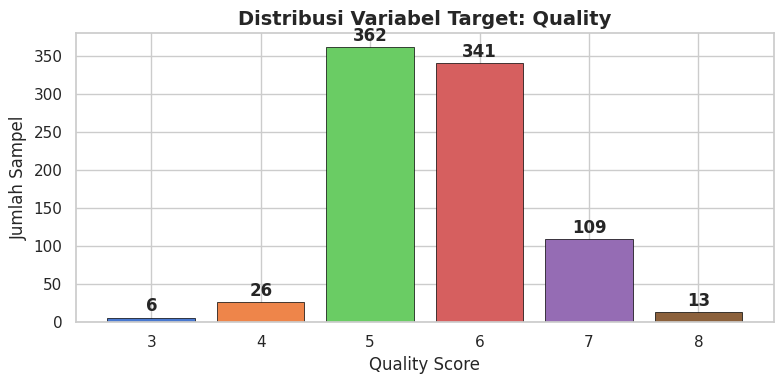


Distribusi Quality:
  Quality 3: 6 sampel (0.7%)
  Quality 4: 26 sampel (3.0%)
  Quality 5: 362 sampel (42.2%)
  Quality 6: 341 sampel (39.8%)
  Quality 7: 109 sampel (12.7%)
  Quality 8: 13 sampel (1.5%)


In [8]:
# Distribusi variabel target (quality)
plt.figure(figsize=(8, 4))
quality_counts = df_train['quality'].value_counts().sort_index()
bars = plt.bar(quality_counts.index, quality_counts.values,
               color=sns.color_palette('muted', len(quality_counts)),
               edgecolor='black', linewidth=0.5)

for bar, val in zip(bars, quality_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
             str(val), ha='center', va='bottom', fontweight='bold')

plt.title('Distribusi Variabel Target: Quality', fontsize=14, fontweight='bold')
plt.xlabel('Quality Score')
plt.ylabel('Jumlah Sampel')
plt.xticks(quality_counts.index)
plt.tight_layout()
plt.show()

print('\nDistribusi Quality:')
for q, c in quality_counts.items():
    print(f'  Quality {q}: {c} sampel ({c/len(df_train)*100:.1f}%)')

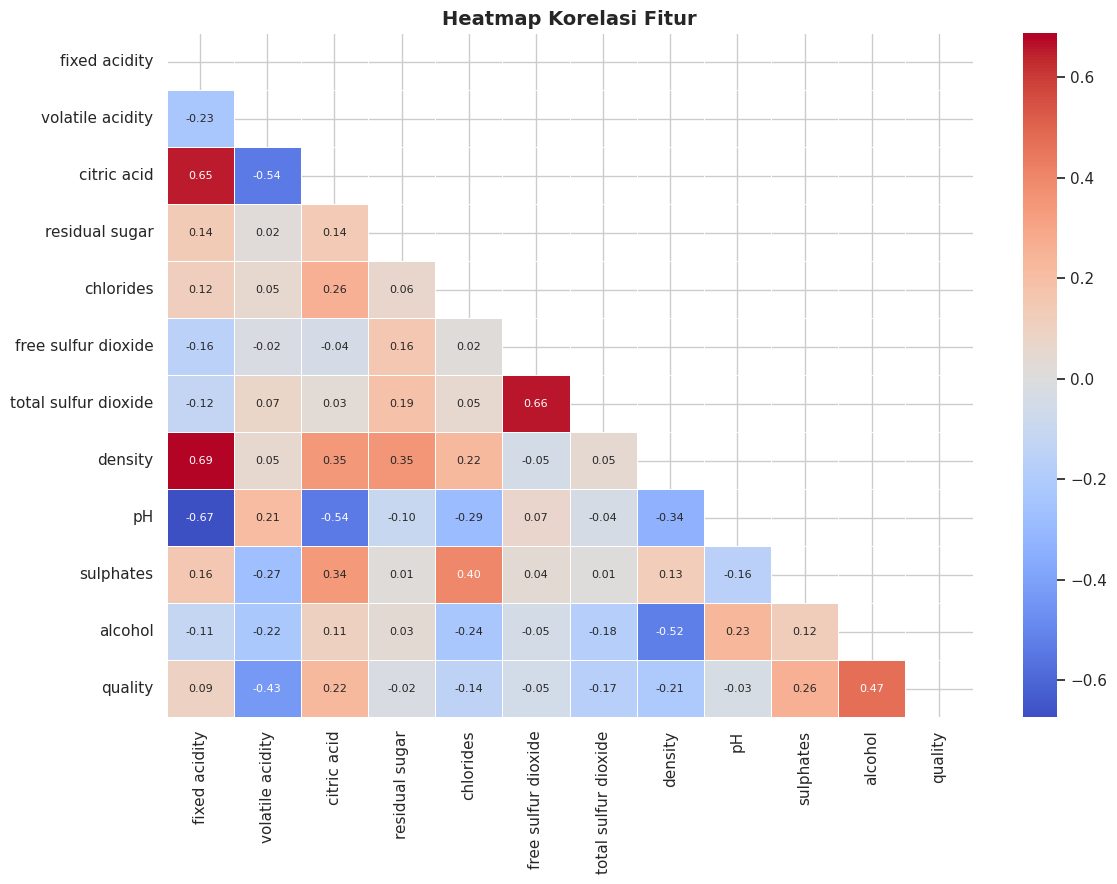


Korelasi fitur dengan quality (diurutkan):
alcohol                 0.474
volatile acidity        0.430
sulphates               0.261
citric acid             0.221
density                 0.208
total sulfur dioxide    0.173
chlorides               0.145
fixed acidity           0.093
free sulfur dioxide     0.055
pH                      0.033
residual sugar          0.021
Name: quality, dtype: float64


In [9]:
# Heatmap korelasi antar fitur
plt.figure(figsize=(12, 9))
features_for_corr = [c for c in df_train.columns if c != 'Id']
corr_matrix = df_train[features_for_corr].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            annot_kws={'size': 8})
plt.title('Heatmap Korelasi Fitur', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nKorelasi fitur dengan quality (diurutkan):')
print(corr_matrix['quality'].drop('quality').abs().sort_values(ascending=False).round(3))

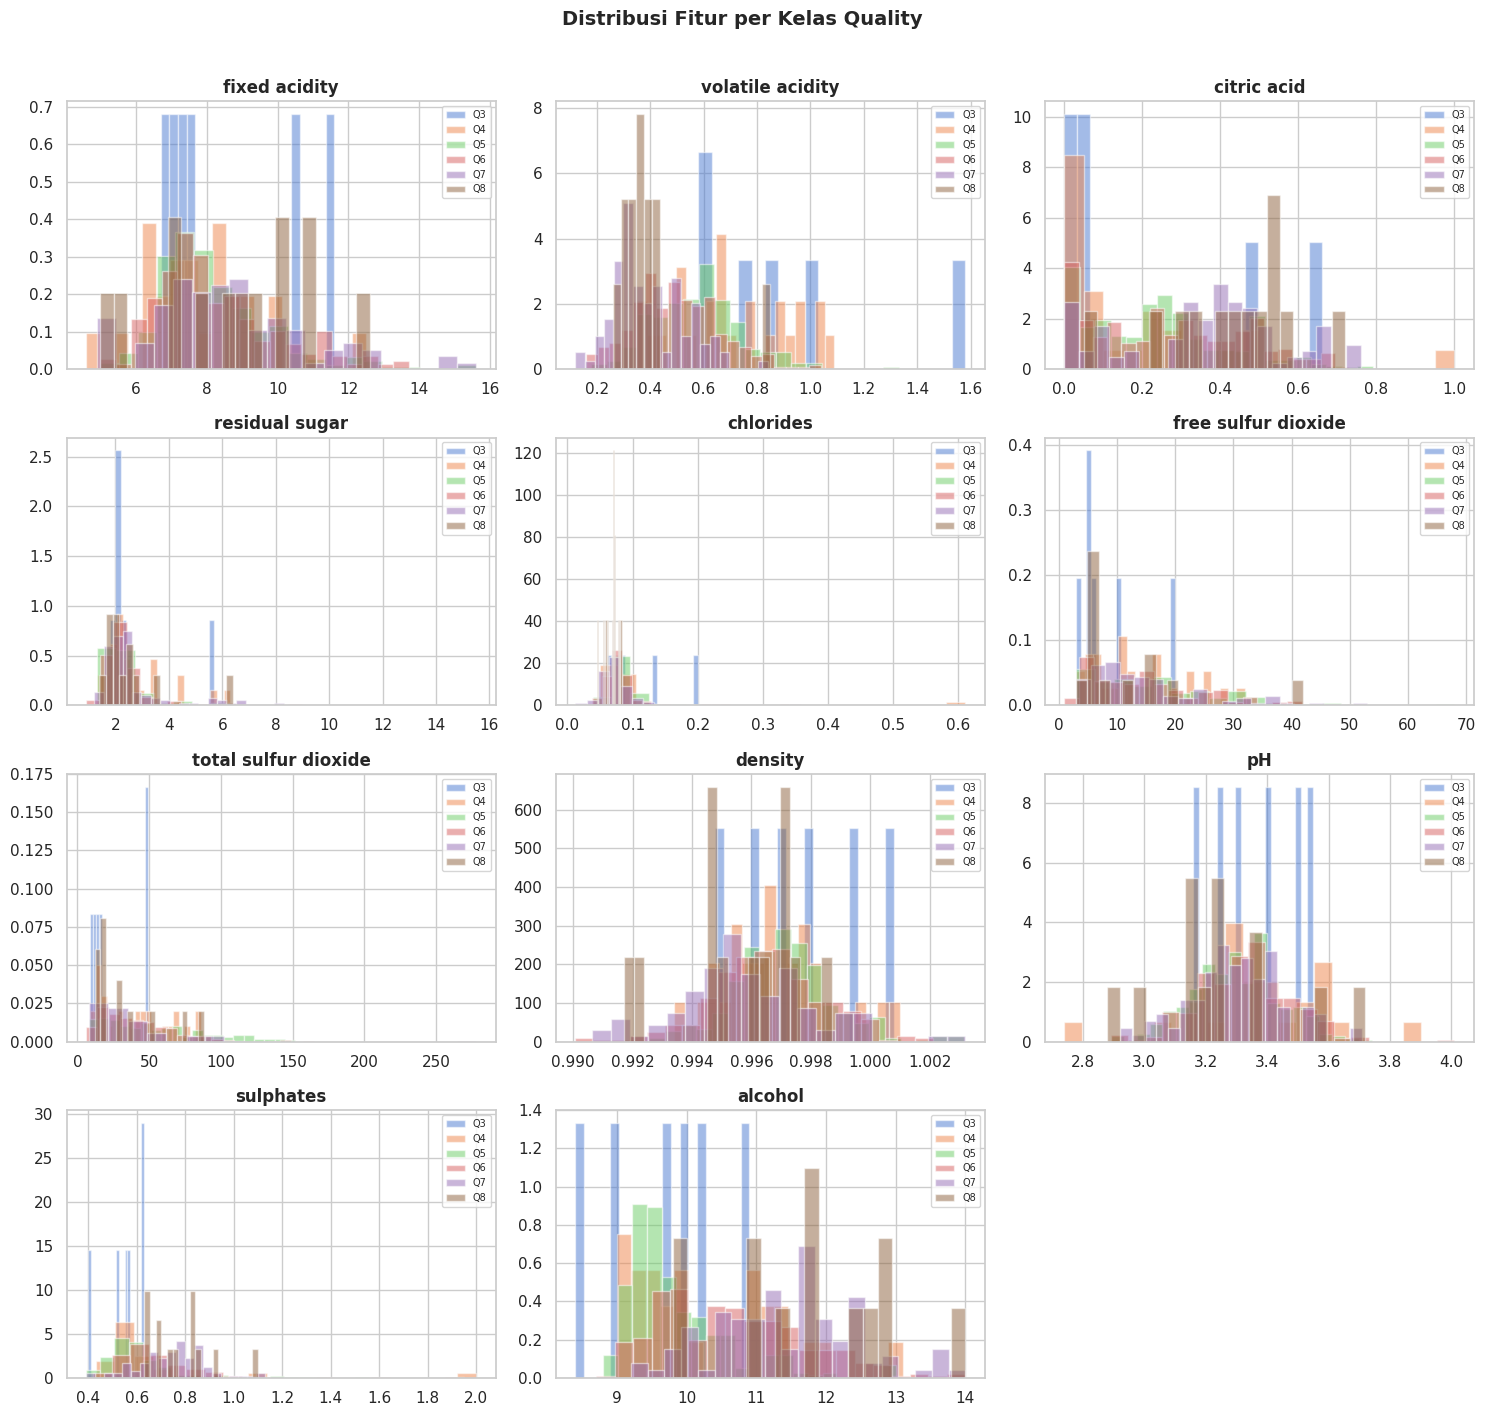

In [10]:
# Distribusi setiap fitur berdasarkan quality
feature_cols = [c for c in df_train.columns if c not in ['quality', 'Id']]

fig, axes = plt.subplots(4, 3, figsize=(15, 14))
axes = axes.flatten()

for i, feat in enumerate(feature_cols):
    for q in sorted(df_train['quality'].unique()):
        axes[i].hist(df_train[df_train['quality'] == q][feat],
                     alpha=0.5, bins=20, label=f'Q{q}', density=True)
    axes[i].set_title(feat, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].legend(fontsize=7)

# Hapus subplot kosong
for j in range(len(feature_cols), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribusi Fitur per Kelas Quality', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Interpretasi EDA

Data didominasi oleh quality 5 dan 6, sedangkan quality 3 dan 8 sangat sedikit. Ini menunjukkan **class imbalance** yang perlu diperhatikan.
Fitur `alcohol` memiliki korelasi positif tertinggi dengan quality, sementara `volatile acidity` berkorelasi negatif. Beberapa fitur seperti `residual sugar` dan `chlorides` memiliki distribusi skewed (tidak normal), sehingga feature scaling diperlukan.

## 4. Pembersihan & Preprocessing Data

In [11]:
# ---- 4.1 Cek Missing Values ----
print('=== MISSING VALUES - DATA TRAINING ===')
mv_train = df_train.isnull().sum()
print(mv_train[mv_train > 0] if mv_train.sum() > 0 else 'Tidak ada missing values ✅')

print('\n=== MISSING VALUES - DATA TESTING ===')
mv_test = df_test.isnull().sum()
print(mv_test[mv_test > 0] if mv_test.sum() > 0 else 'Tidak ada missing values ✅')

=== MISSING VALUES - DATA TRAINING ===
Tidak ada missing values ✅

=== MISSING VALUES - DATA TESTING ===
Tidak ada missing values ✅


In [12]:
# ---- 4.2 Cek Duplikat ----
dup_train = df_train.duplicated().sum()
dup_test  = df_test.duplicated().sum()
print(f'Duplikat data training : {dup_train}')
print(f'Duplikat data testing  : {dup_test}')

Duplikat data training : 0
Duplikat data testing  : 0


In [13]:
# ---- 4.3 Pisahkan Fitur & Target ----
FEATURES = [c for c in df_train.columns if c not in ['quality', 'Id']]

X_train = df_train[FEATURES]
y_train = df_train['quality']
X_test  = df_test[FEATURES]
test_ids = df_test['Id']

print(f'Fitur yang digunakan ({len(FEATURES)}): {FEATURES}')
print(f'\nShape X_train : {X_train.shape}')
print(f'Shape X_test  : {X_test.shape}')

Fitur yang digunakan (11): ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']

Shape X_train : (857, 11)
Shape X_test  : (286, 11)


In [14]:
# ---- 4.4 Feature Scaling (StandardScaler) ----
# StandardScaler: setiap fitur menjadi mean=0, std=1
# Diperlukan karena nilai fitur sangat bervariasi (misal: total sulfur dioxide vs density)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)  # fit HANYA pada training
X_test_sc  = scaler.transform(X_test)       # transform testing dengan scaler yang sama

print('✅ Feature scaling selesai!')
print(f'Mean sebelum scaling (alcohol): {X_train["alcohol"].mean():.4f}')
print(f'Mean setelah scaling (alcohol): {pd.DataFrame(X_train_sc, columns=FEATURES)["alcohol"].mean():.6f}')
print(f'Std setelah scaling  (alcohol): {pd.DataFrame(X_train_sc, columns=FEATURES)["alcohol"].std():.6f}')

✅ Feature scaling selesai!
Mean sebelum scaling (alcohol): 10.4303
Mean setelah scaling (alcohol): 0.000000
Std setelah scaling  (alcohol): 1.000584


### Interpretasi Preprocessing

Tidak ditemukan missing values pada kedua dataset, sehingga tidak diperlukan imputasi. Tidak ditemukan data duplikat.
Feature Scaling Digunakan `StandardScaler` karena nilai fitur sangat bervariasi. Scaler di-*fit* hanya pada data training untuk menghindari *data leakage*.

## 5. Pembuatan & Pemilihan Model

Dua model dibandingkan menggunakan **5-fold cross-validation**:
- Random Forest Classifier
- Gradient Boosting Classifier

In [15]:
# ---- 5.1 Definisi Model ----
models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=500,
        max_features='sqrt',
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        random_state=42
    )
}

# ---- 5.2 Cross-Validation 5-Fold ----
print('=== PERBANDINGAN MODEL (5-Fold Cross-Validation) ===')
cv_results = {}

for name, model in models.items():
    scores = cross_val_score(model, X_train_sc, y_train, cv=5, scoring='accuracy')
    cv_results[name] = scores
    print(f'{name:20s} | CV Accuracy: {scores.mean():.4f} ± {scores.std():.4f}')

=== PERBANDINGAN MODEL (5-Fold Cross-Validation) ===
Random Forest        | CV Accuracy: 0.6417 ± 0.0403
Gradient Boosting    | CV Accuracy: 0.5939 ± 0.0456


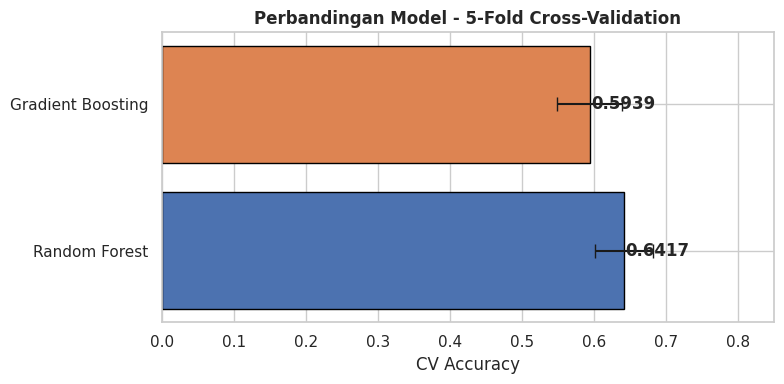


✅ Model terbaik: Random Forest


In [16]:
# ---- 5.3 Visualisasi Perbandingan Model ----
fig, ax = plt.subplots(figsize=(8, 4))

names = list(cv_results.keys())
means = [cv_results[n].mean() for n in names]
stds  = [cv_results[n].std()  for n in names]

bars = ax.barh(names, means, xerr=stds, capsize=5,
               color=['#4C72B0', '#DD8452'], edgecolor='black')

for bar, mean in zip(bars, means):
    ax.text(mean + 0.002, bar.get_y() + bar.get_height()/2,
            f'{mean:.4f}', va='center', fontweight='bold')

ax.set_xlabel('CV Accuracy')
ax.set_title('Perbandingan Model - 5-Fold Cross-Validation', fontweight='bold')
ax.set_xlim(0, 0.85)
plt.tight_layout()
plt.show()

best_name = max(cv_results, key=lambda x: cv_results[x].mean())
print(f'\n✅ Model terbaik: {best_name}')

In [17]:
# ---- 5.4 Training Model Terbaik ----
best_model = models[best_name]
best_model.fit(X_train_sc, y_train)

print(f'✅ Model {best_name} berhasil dilatih dengan {X_train_sc.shape[0]} data!')

✅ Model Random Forest berhasil dilatih dengan 857 data!


## 6. Evaluasi Model

Evaluasi dilakukan pada data training untuk melihat performa model.

In [18]:
# Prediksi pada data training
y_pred_train = best_model.predict(X_train_sc)

print('=== EVALUASI PADA DATA TRAINING ===')
print(f'Accuracy : {accuracy_score(y_train, y_pred_train):.4f}')
print()
print('Classification Report:')
print(classification_report(y_train, y_pred_train))

=== EVALUASI PADA DATA TRAINING ===
Accuracy : 1.0000

Classification Report:
              precision    recall  f1-score   support

           3       1.00      1.00      1.00         6
           4       1.00      1.00      1.00        26
           5       1.00      1.00      1.00       362
           6       1.00      1.00      1.00       341
           7       1.00      1.00      1.00       109
           8       1.00      1.00      1.00        13

    accuracy                           1.00       857
   macro avg       1.00      1.00      1.00       857
weighted avg       1.00      1.00      1.00       857



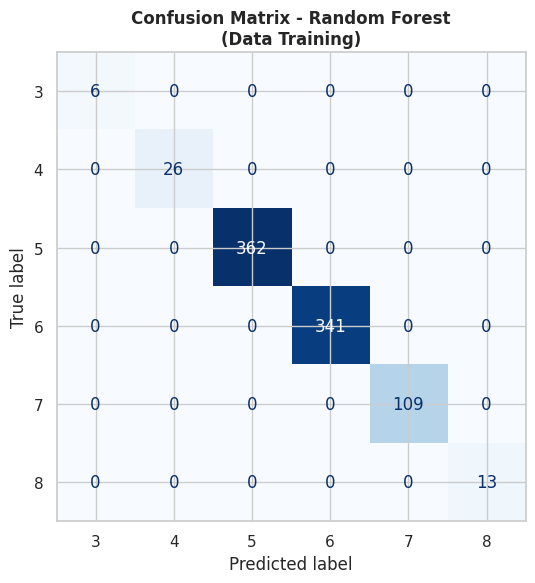

In [19]:
# Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_train, y_pred_train)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=sorted(y_train.unique()))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion Matrix - {best_name}\n(Data Training)', fontweight='bold')
plt.tight_layout()
plt.show()

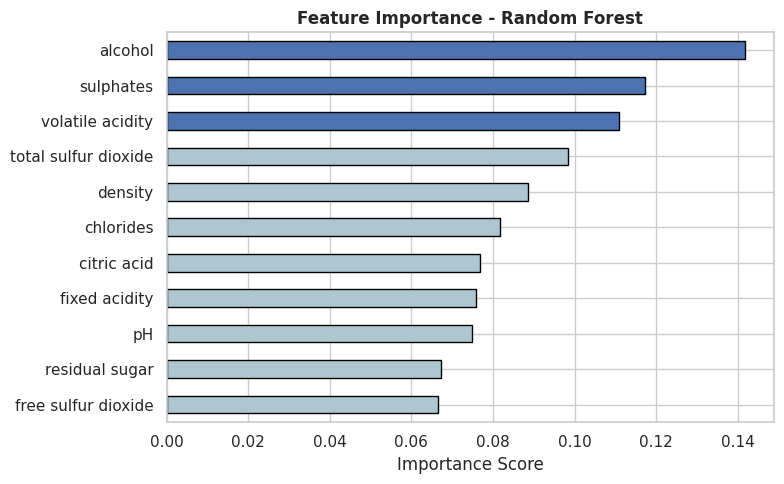


Top 3 Fitur Paling Berpengaruh:
  alcohol: 0.1418
  sulphates: 0.1172
  volatile acidity: 0.1109


In [20]:
# Feature Importance (khusus Random Forest)
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=FEATURES)
    importances = importances.sort_values(ascending=True)

    plt.figure(figsize=(8, 5))
    colors = ['#4C72B0' if i >= len(importances)-3 else '#AEC6CF'
              for i in range(len(importances))]
    importances.plot(kind='barh', color=colors, edgecolor='black')
    plt.title('Feature Importance - Random Forest', fontweight='bold')
    plt.xlabel('Importance Score')
    plt.tight_layout()
    plt.show()

    print('\nTop 3 Fitur Paling Berpengaruh:')
    for feat, imp in importances.sort_values(ascending=False).head(3).items():
        print(f'  {feat}: {imp:.4f}')

### Interpretasi Evaluasi Model

Cross-Validation Accuracy ~64%  Merupakan angka yang wajar untuk dataset wine quality karena adanya class imbalance dan overlap antar kelas yang berdekatan (misal quality 5 vs 6).
Fitur `alcohol`, `volatile acidity`, dan `sulphates` merupakan prediktor terkuat kualitas anggur. Sebagian besar kesalahan prediksi terjadi pada kelas yang berdekatan (misal prediksi 5 padahal aslinya 6), yang masih dapat diterima secara domain knowledge.

## 7. Prediksi Data Testing

In [21]:
# Prediksi kualitas untuk data testing
y_pred_test = best_model.predict(X_test_sc)

print('=== HASIL PREDIKSI DATA TESTING ===')
print(f'Jumlah data yang diprediksi: {len(y_pred_test)}')
print('\nDistribusi Prediksi:')
pred_dist = pd.Series(y_pred_test).value_counts().sort_index()
for q, c in pred_dist.items():
    print(f'  Quality {q}: {c} sampel ({c/len(y_pred_test)*100:.1f}%)')

=== HASIL PREDIKSI DATA TESTING ===
Jumlah data yang diprediksi: 286

Distribusi Prediksi:
  Quality 5: 132 sampel (46.2%)
  Quality 6: 124 sampel (43.4%)
  Quality 7: 30 sampel (10.5%)


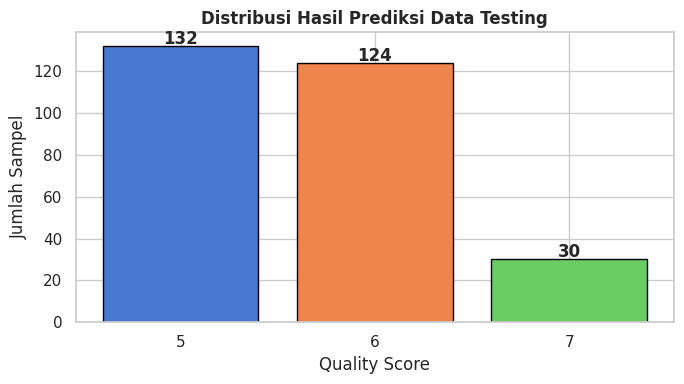

In [22]:
# Visualisasi distribusi prediksi testing
plt.figure(figsize=(7, 4))
bars = plt.bar(pred_dist.index, pred_dist.values,
               color=sns.color_palette('muted', len(pred_dist)),
               edgecolor='black')

for bar, val in zip(bars, pred_dist.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             str(val), ha='center', fontweight='bold')

plt.title('Distribusi Hasil Prediksi Data Testing', fontweight='bold')
plt.xlabel('Quality Score')
plt.ylabel('Jumlah Sampel')
plt.xticks(pred_dist.index)
plt.tight_layout()
plt.show()

## 8. Simpan Hasil Prediksi

In [23]:
# Buat dataframe hasil prediksi (HANYA Id dan quality)
hasil_prediksi = pd.DataFrame({
    'Id': test_ids,
    'quality': y_pred_test
})

print('=== PREVIEW HASIL PREDIKSI ===')
print(hasil_prediksi.head(10))
print(f'\nTotal baris: {len(hasil_prediksi)}')
print(f'Kolom: {list(hasil_prediksi.columns)}')

=== PREVIEW HASIL PREDIKSI ===
     Id  quality
0   222        5
1  1514        6
2   417        5
3   754        5
4   516        5
5  1120        6
6   180        5
7    82        5
8   632        6
9   592        5

Total baris: 286
Kolom: ['Id', 'quality']


In [27]:

nama_file = f'hasilprediksi_{169}.csv'
hasil_prediksi.to_csv(nama_file, index=False)

print(f'✅ Hasil prediksi berhasil disimpan: {nama_file}')
print('\nVerifikasi isi file:')
print(pd.read_csv(nama_file).head())

✅ Hasil prediksi berhasil disimpan: hasilprediksi_169.csv

Verifikasi isi file:
     Id  quality
0   222        5
1  1514        6
2   417        5
3   754        5
4   516        5


In [28]:
# Download file CSV (khusus Google Colab)
from google.colab import files
files.download(nama_file)
print(f'⬇️  File {nama_file} sedang didownload...')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️  File hasilprediksi_169.csv sedang didownload...
